In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from statsmodels.tsa.stattools import adfuller



PROJECT_ROOT = Path.cwd()
p = Path.cwd().resolve()
while p != p.parent and not (p / "extending_obs_space_analysis").exists():
    p = p.parent
PROJECT_ROOT = p

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Using project root:", PROJECT_ROOT)

from pathlib import Path
from extending_obs_space_analysis.prepare_data import PipelinePaths, build_training_dataframe

paths = PipelinePaths(
    drl_csv=Path("../data/data_2019-01-01_2024-12-31_hourly.csv"),
    ri_profit_2019_csv=Path("../output/single_market/rolling_intrinsic/ri_basic/qh/2019/bs15cr1rto0.86mc365mt10/profit.csv"),
    ri_profit_2023_csv=Path("../output/single_market/rolling_intrinsic/ri_basic/qh/2023/bs15cr1rto0.86mc365mt10/profit.csv"),
    da_milp_exaa_csv=Path("../output/myopic_multi_market/day_ahead_milp/da_milp_results_exaa.csv"),
    da_milp_epex_csv=Path("../output/myopic_multi_market/day_ahead_milp/da_milp_results_epex.csv"),
)

df_daily = build_training_dataframe(paths, date_slice=("2019-01-01", "2023-12-31"))


Using project root: /Users/timflaschel/Documents/GitHub/BessBidder1


<Axes: title={'center': 'Profit over Time'}, xlabel='date'>

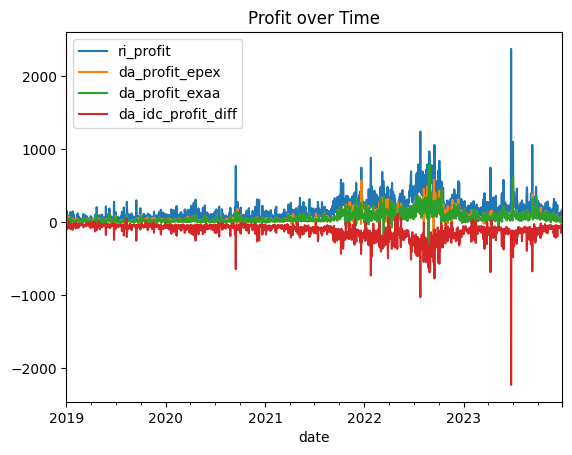

In [3]:
df_daily[["ri_profit", "da_profit_epex", "da_profit_exaa", "da_idc_profit_diff"]].plot(title="Profit over Time")

In [4]:
df_daily[[
    "ri_profit",
    "da_profit_epex",
    "da_idc_profit_diff"
]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])

,ri_profit,da_profit_epex,da_idc_profit_diff
count,1826.000000,1826.000000,1826.000000
mean,179.591671,66.708093,-112.883578
std,156.884145,74.919473,110.789202
min,17.538780,-176.526132,-2225.924762
5%,41.320112,7.589432,-303.153336
25%,74.912292,19.437774,-143.085730
50%,129.876447,41.834264,-81.857635
75%,233.856328,91.727302,-49.529689
95%,476.780762,211.928817,-21.588350
max,2377.600615,635.517841,120.146749


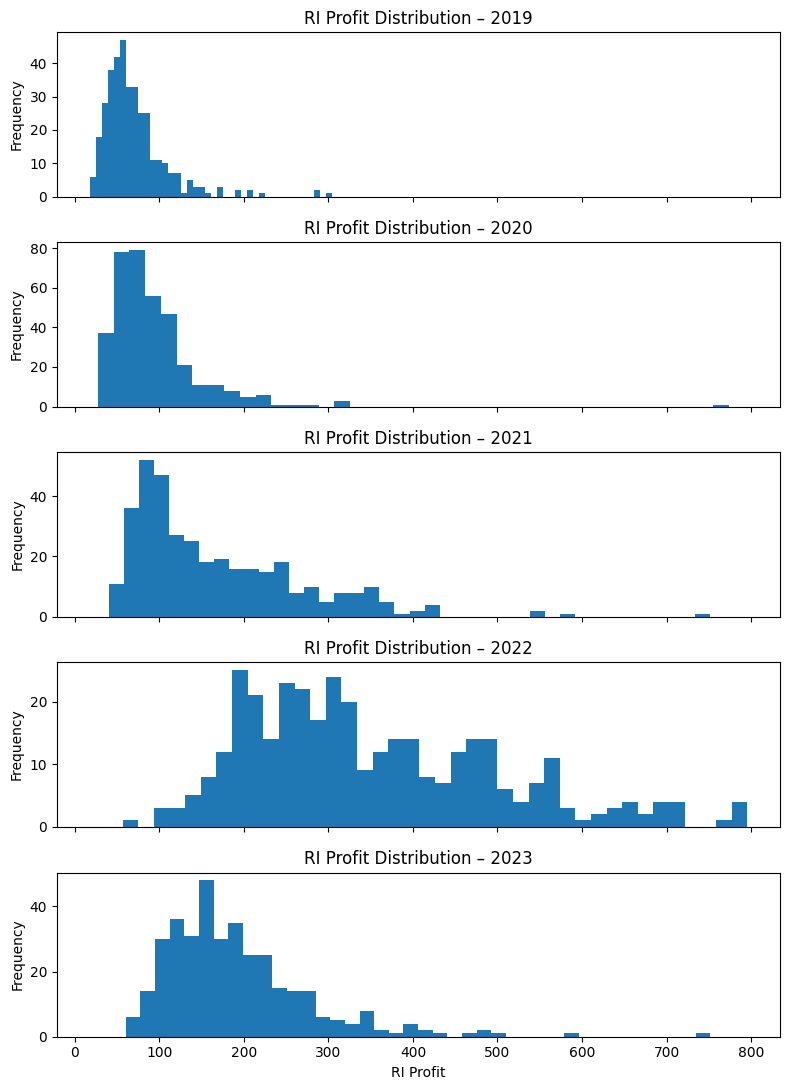

In [5]:
years = sorted(df_daily["year"].unique())
n_years = len(years)

fig, axes = plt.subplots(
    n_years, 1,
    figsize=(8, 2.2 * n_years),
    sharex=True
)

q_cut = df_daily["ri_profit"].quantile(0.995)


for ax, year in zip(axes, years):
    data = df_daily.loc[
        (df_daily["year"] == year)
        & (df_daily["ri_profit"] <= q_cut),
        "ri_profit"
    ]
    ax.hist(data, bins=40)
    ax.set_title(f"RI Profit Distribution – {year}")
    ax.set_ylabel("Frequency")

axes[-1].set_xlabel("RI Profit")
plt.tight_layout()


<Figure size 1000x500 with 0 Axes>

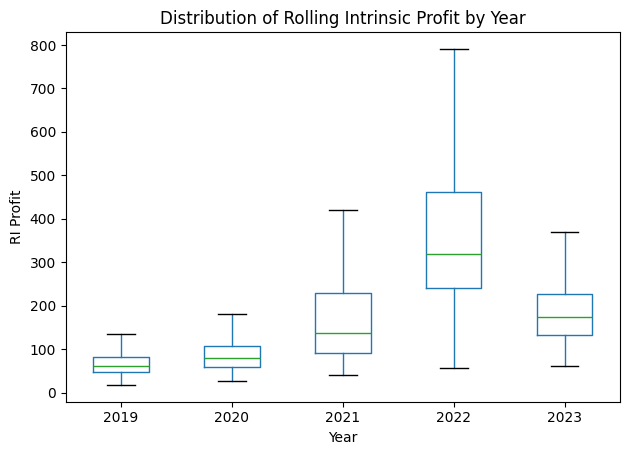

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
df_daily.boxplot(
    column="ri_profit",
    by="year",
    showfliers=False
)

plt.title("Distribution of Rolling Intrinsic Profit by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("RI Profit")
plt.grid(False)
plt.tight_layout()

In [7]:
df_daily[[
    "ri_profit",
    "da_profit_epex",
    "da_profit_exaa",
    "da_idc_profit_diff"
]].corr()


,ri_profit,da_profit_epex,da_profit_exaa,da_idc_profit_diff
ri_profit,1.000000,0.763647,0.729739,-0.899656
da_profit_epex,0.763647,1.000000,0.796146,-0.405135
da_profit_exaa,0.729739,0.796146,1.000000,-0.494972
da_idc_profit_diff,-0.899656,-0.405135,-0.494972,1.000000


In [10]:
corr_with_profit = (
    df_daily
    .corr(method="pearson")["ri_profit"]
    .sort_values(ascending=False)
)

corr_with_profit.head(30)

ri_profit                             1.000000
id_full_h_std                         0.876459
epex_price_spread                     0.855915
epex_price_std                        0.854439
epex_price_delta_sum                  0.850215
id_full_h_spread                      0.846291
id_full_h_max                         0.841028
epex_price_delta_max                  0.829523
exaa_price_std                        0.815333
exaa_price_delta_sum                  0.803533
exaa_price_spread                     0.800940
exaa_std_roll3d_mean_lag0             0.794646
exaa_spread_roll3d_mean_lag0          0.789718
epex_price_max                        0.777600
exaa_std_roll7d_mean_lag0             0.773741
exaa_spread_roll7d_mean_lag0          0.772805
epex_spread_roll7d_mean_lag1          0.764701
da_profit_epex                        0.763647
epex_spread_roll3d_mean_lag1          0.760180
exaa_std_roll14d_mean_lag0            0.757732
exaa_spread_roll14d_mean_lag0         0.757245
epex_spread_r

Text(0.5, 0, 'exaa_price_std')

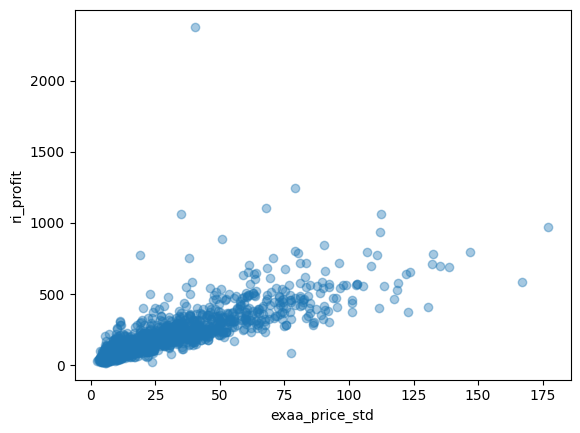

In [9]:
plt.scatter(
   # df_daily["da_profit_epex"],
    df_daily["exaa_price_std"],
    df_daily["ri_profit"],
    alpha=0.4
)
plt.ylabel(df_daily["ri_profit"].name)
plt.xlabel(df_daily["exaa_price_std"].name)


In [ ]:
df_sorted = df_daily.sort_values("ri_profit", ascending=False)

df_sorted["cum_profit_share"] = (
    df_sorted["ri_profit"].cumsum() /
    df_sorted["ri_profit"].sum()
)

threshold = df_sorted.loc[
    df_sorted["cum_profit_share"] >= 0.5,
    "ri_profit"
].iloc[0]

df_daily["ri_high"] = (
    df_daily["ri_profit"] >= threshold
).astype(int)


share_days = df_daily["ri_high"].mean()
print(f"High RI days share: {share_days}")

High RI days share: 0.2212486308871851


In [ ]:
df = df_daily.copy()

results = []

for year, g in df.groupby("year"):
    g_sorted = g.sort_values("ri_profit", ascending=False)

    cum_share = g_sorted["ri_profit"].cumsum() / g_sorted["ri_profit"].sum()

    threshold = g_sorted.loc[cum_share >= 0.5, "ri_profit"].iloc[0]

    share_days = (g["ri_profit"] >= threshold).mean()

    results.append({
        "year": year,
        "ri_threshold_50pct_profit": threshold,
        "share_high_ri_days": share_days,
        "n_days": len(g)
    })

df_yearly_summary = pd.DataFrame(results).set_index("year")

print(df_yearly_summary)


      ri_threshold_50pct_profit  share_high_ri_days  n_days
year                                                       
2019                  77.279816            0.317808     365
2020                 102.340703            0.306011     366
2021                 215.188279            0.279452     365
2022                 409.349106            0.323288     365
2023                 212.984398            0.315068     365
